In [1]:
import pandas as pd
import numpy as np
import sys
import os
import joblib

# import some libraries for training
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score
import torch.nn as nn
import torch.optim as optim

from helper_modules import phase1_preprocess_data, phase2_preprocess_data, perform_one_hot_encode

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)


### Read in the (test/submission) data

In [2]:
df_test = pd.read_csv(os.path.join('datasets', 'flextrack_phase1_test.csv'))
df_test = df_test.sort_values(by=['Site', 'Timestamp_Local'])
# df_test = pd.read_csv(os.path.join('datasets', 'flextrack_phase1_test_partial.csv'))
df_test['Demand_Response_Capacity_kW'] = np.nan  # Add the target column with NaN values
print(df_test.shape)
display(df_test.head())

(105120, 7)


,Site,Timestamp_Local,Dry_Bulb_Temperature_C,Global_Horizontal_Radiation_W/m2,Building_Power_kW,Demand_Response_Flag,Demand_Response_Capacity_kW
0,siteD,2020-01-01 00:00:00,24.70,0,4.8,0.0,NaN
1,siteD,2020-01-01 00:15:00,24.61,0,4.8,0.0,NaN
2,siteD,2020-01-01 00:30:00,24.53,0,4.8,0.0,NaN
3,siteD,2020-01-01 00:45:00,24.45,0,4.8,0.0,NaN
4,siteD,2020-01-01 01:00:00,24.36,0,4.8,0.0,NaN


In [3]:
# Separate df_test into two parts: null and not null for 'Demand_Response_Flag'
df_test_null = df_test[df_test['Demand_Response_Flag'].isnull()].copy(deep=True)
df_test_notnull = df_test[~df_test['Demand_Response_Flag'].isnull()].copy(deep=True)

### Stage 1 Predictions -- Classifying Demand_Response_Flag
- Only do this for df_test_null

In [4]:
# perform some preprocessing for phase 1
df = phase1_preprocess_data(df_test_null)
df.drop(columns=['Demand_Response_Flag'], inplace=True)

In [5]:
# Load the trained model from file
from net_architecture import Net    # Define the neural network architecture: Just need to load architecture defined in net_architecture.py
input_dim = df.shape[1]             # Number of features
num_classes = 3                     # Number of classes in target variable
model_loaded = Net(input_dim, num_classes)
model_loaded.load_state_dict(torch.load('./models/phase1_nn_model.pth'))

# load the scaler, which should be ColumnTransformer type
# scaler is a combination of PowerTransformer (Yeo-Johnson transformation) & StandardScaler
scaler = joblib.load('./models/phase1_scaler.pkl')
print(scaler)

ColumnTransformer(transformers=[('bin_pass', 'passthrough',
                                 ['is_daylight', 'Is_Weekend', 'Is_Summer',
                                  'Is_Winter', 'Is_Afternoon', 'Is_Evening']),
                                ('yj_std',
                                 Pipeline(steps=[('yeojohnson',
                                                  PowerTransformer(standardize=False)),
                                                 ('std', StandardScaler())]),
                                 ['Dry_Bulb_Temperature_C',
                                  'Global_Horizontal_Radiation_W/m2',
                                  'Building_Power_kW', 'Hour', 'Day', 'DOW',
                                  'Month', 'Weekday', 'Minute', 'Hour_sin',
                                  'Hour_cos', 'DOW_sin', 'DOW_cos', 'HDD18',
                                  'CDD22', 'TempC2', 'rad_sqrt', 'rad_log1p',
                                  'TempC_x_daylight', 'CDD22_x_daylight'])

In [6]:
# Convert DataFrame to torch tensor
X = scaler.transform(df)
X = torch.tensor(X, dtype=torch.float32)

# Set model to evaluation mode
model_loaded.eval()
with torch.no_grad():
    outputs = model_loaded(X)
    predictions = torch.argmax(outputs, dim=1)

# convert 2 in predictions to -1
predictions = np.where(predictions == 2, -1, predictions)

# Calculate the distribution of predictions classes
unique, counts = np.unique(predictions, return_counts=True)
distribution_pred = dict(zip(unique, counts))
print(distribution_pred)

{np.int64(-1): np.int64(10324), np.int64(0): np.int64(51014), np.int64(1): np.int64(8742)}


In [7]:
df_test_null.head()

,Site,Timestamp_Local,Dry_Bulb_Temperature_C,Global_Horizontal_Radiation_W/m2,Building_Power_kW,Demand_Response_Flag,Demand_Response_Capacity_kW
35040,siteE,2020-01-01 00:00:00,15.50,0,4.8,NaN,NaN
35041,siteE,2020-01-01 00:15:00,15.17,0,4.8,NaN,NaN
35042,siteE,2020-01-01 00:30:00,14.85,0,4.8,NaN,NaN
35043,siteE,2020-01-01 00:45:00,14.52,0,4.8,NaN,NaN
35044,siteE,2020-01-01 01:00:00,14.20,0,4.8,NaN,NaN


In [8]:
# Prepare data for Stage 2 predictions:
# make predictions for df_test_null by using the predictions from Stage 1
df_stage2 = df_test_null.drop(columns=['Demand_Response_Flag'])
df_stage2['Demand_Response_Flag'] = predictions
# then combine df_test_null and df_test_notnull back to df_stage2
df_stage2 = pd.concat([df_stage2, df_test_notnull], axis=0)
df_stage2 = df_stage2.sort_values(by=['Site', 'Timestamp_Local'])
df_stage2.reset_index(drop=True, inplace=True)

### Stage 2 Predictions - Demand_Response_Capacity_kW

In [9]:
# # In df_stage2, if Demand_Response_Flag = 0, set Demand_Response_Capacity_kW = 0
# df_stage2.loc[df_stage2['Demand_Response_Flag'] == 0, 'Demand_Response_Capacity_kW'] = 0.0
# # Separate df_stage2 into two parts: zero and non-zero for 'Demand_Response_Flag'
# df_stage2_zero = df_stage2[df_stage2['Demand_Response_Flag'] == 0].copy(deep=True)
# df_stage2_nz   = df_stage2[df_stage2['Demand_Response_Flag'] != 0].copy(deep=True)

# # Only do phase 2 regression on df_stage2_nz
# # perform some preprocessing for phase 2
# df = phase2_preprocess_data(df_stage2_nz)
# df.drop(columns=['Demand_Response_Capacity_kW'], inplace=True)
# df.head()


df = phase2_preprocess_data(df_stage2)
df = perform_one_hot_encode(df, col_name='Demand_Response_Flag')
df.drop(columns=['Demand_Response_Capacity_kW'], inplace=True)
df.head()

,quarter,month,week,day,dow,doy,hour,minute,second,is_weekend,is_month_start,is_month_end,is_quarter_end,is_year_end,P_lag_1,P_lag_1h,P_lag_3h,P_lag_6h,P_lag_24h,P_same_hour_yday,P_same_hour_lweek,P_delta_1,P_pctchg_1,W_lag_1,W_lag_1h,W_lag_3h,W_lag_6h,W_lag_24h,W_same_hour_yday,W_same_hour_lweek,W_delta_1,W_pctchg_1,T_lag_1,T_lag_1h,T_lag_3h,T_lag_6h,T_lag_24h,T_same_hour_yday,T_same_hour_lweek,T_delta_1,T_pctchg_1,Demand_Response_Flag_-1,Demand_Response_Flag_0,Demand_Response_Flag_1
0,1,1,1,1,2,1,11,0,0,0,1,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,0
1,1,1,1,1,2,1,11,0,0,0,1,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,0
2,1,1,1,1,2,1,11,15,0,0,1,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,0
3,1,1,1,1,2,1,11,15,0,0,1,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,0
4,1,1,1,1,2,1,11,30,0,0,1,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,0


In [10]:
# Load models
clf_nz = joblib.load('./models/phase2_xgb_clf_nz_model.pkl')
reg_nz = joblib.load('./models/phase2_xgb_reg_nz_model.pkl')

# Prepare test features (X_test)
X_test = df.values

# Predict on real test set
p_nz = clf_nz.predict_proba(X_test)[:, 1]
mu_nz = reg_nz.predict(X_test)
y_pred_xgb = p_nz * mu_nz

In [11]:
df_stage2['Demand_Response_Capacity_kW'] = y_pred_xgb

# df_stage2_nz['Demand_Response_Capacity_kW'] = y_pred_xgb
# df_stage2 = pd.concat([df_stage2_zero, df_stage2_nz], axis=0)
# df_stage2 = df_stage2.sort_values(by=['Site', 'Timestamp_Local'])
# df_stage2.reset_index(drop=True, inplace=True)
# # Here we should have every needed column to submit

In [12]:
df_submission = df_stage2[['Site', 'Timestamp_Local','Demand_Response_Flag','Demand_Response_Capacity_kW']].copy(deep=True)
df_submission = df_submission.sort_values(by=['Site', 'Timestamp_Local'])
df_submission.reset_index(drop=True, inplace=True)

# manually enforce 0 for Demand_Response_Capacity_kW if Demand_Response_Flag = 0
df_submission.loc[df_submission['Demand_Response_Flag'] == 0, 'Demand_Response_Capacity_kW'] = 0.0

df_submission.to_csv('./submissions/submission.csv', index=False)
print("Submission file created: submission.csv in ./submissions folder")

Submission file created: submission.csv in ./submissions folder


In [13]:
# df_submission = df_test[['Site', 'Timestamp_Local']].copy(deep=True)
# df_submission['Demand_Response_Flag'] = predictions
# df_submission['Demand_Response_Capacity_kW'] = y_pred_xgb

# # manually enforce 0 for Demand_Response_Capacity_kW if Demand_Response_Flag = 0
# df_submission.loc[df_submission['Demand_Response_Flag'] == 0, 'Demand_Response_Capacity_kW'] = 0

# df_pred_partial = pd.read_csv(os.path.join('submissions', 'flextrack_phase1_test_partial_predictions.csv'))
# df_submission = pd.concat([df_submission, df_pred_partial], axis=0)
# df_submission = df_submission.sort_values(by=['Site', 'Timestamp_Local']).reset_index(drop=True)

# df_submission.to_csv('./submissions/submission.csv', index=False)
# print("Submission file created: submission.csv in ./submissions folder")

In [14]:
display(df_submission.head())
print('submission file shape:', df_submission.shape)
df_submission['Demand_Response_Flag'].value_counts()

,Site,Timestamp_Local,Demand_Response_Flag,Demand_Response_Capacity_kW
0,siteD,2020-01-01 00:00:00,0.0,0.0
1,siteD,2020-01-01 00:15:00,0.0,0.0
2,siteD,2020-01-01 00:30:00,0.0,0.0
3,siteD,2020-01-01 00:45:00,0.0,0.0
4,siteD,2020-01-01 01:00:00,0.0,0.0


submission file shape: (105120, 4)


Demand_Response_Flag
 0.0    85083
-1.0    11034
 1.0     9003
Name: count, dtype: int64

<Axes: >

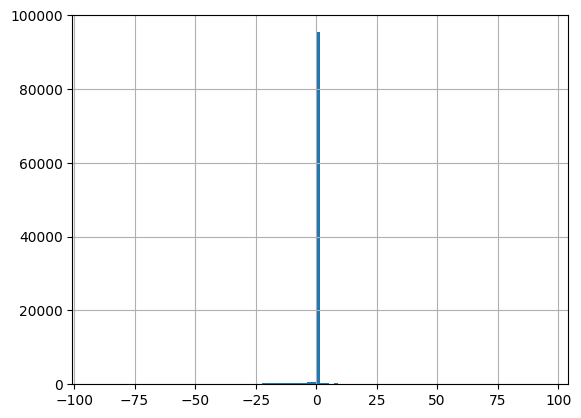

In [15]:
df_submission['Demand_Response_Capacity_kW'].hist(bins=100)

-91.39376 94.88433 0.38973728 0.0


<Axes: >

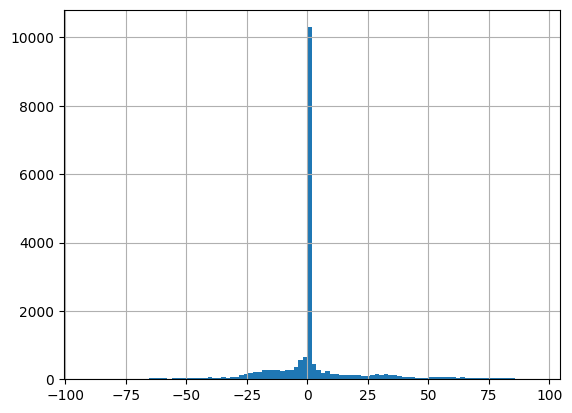

In [16]:
regression_values = df_submission['Demand_Response_Capacity_kW'].values
print(np.min(regression_values), np.max(regression_values), np.mean(regression_values), np.median(regression_values))
df_submission[
    df_submission['Demand_Response_Capacity_kW'] != 0
]['Demand_Response_Capacity_kW'].hist(bins=100)

In [17]:
df.head()

,quarter,month,week,day,dow,doy,hour,minute,second,is_weekend,is_month_start,is_month_end,is_quarter_end,is_year_end,P_lag_1,P_lag_1h,P_lag_3h,P_lag_6h,P_lag_24h,P_same_hour_yday,P_same_hour_lweek,P_delta_1,P_pctchg_1,W_lag_1,W_lag_1h,W_lag_3h,W_lag_6h,W_lag_24h,W_same_hour_yday,W_same_hour_lweek,W_delta_1,W_pctchg_1,T_lag_1,T_lag_1h,T_lag_3h,T_lag_6h,T_lag_24h,T_same_hour_yday,T_same_hour_lweek,T_delta_1,T_pctchg_1,Demand_Response_Flag_-1,Demand_Response_Flag_0,Demand_Response_Flag_1
0,1,1,1,1,2,1,11,0,0,0,1,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,0
1,1,1,1,1,2,1,11,0,0,0,1,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,0
2,1,1,1,1,2,1,11,15,0,0,1,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,0
3,1,1,1,1,2,1,11,15,0,0,1,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,0
4,1,1,1,1,2,1,11,30,0,0,1,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,0
